# 🚗 Car Breakdown Prediction - Machine Learning Assignment

## 📋 Project Overview
**Doel**: Voorspel of een voertuig binnen 30 dagen een mechanische storing zal hebben.

**Bron**: [Kaggle Competition](https://www.kaggle.com/competitions/car-breakdown-prediction)

**Data Locatie**: `src/train_CarBreakDown.csv` en `src/test_CarBreakDown.csv`

## 🎯 Taak
Gegeven 13 features over een auto (brand, leeftijd, kilometers, onderhoud, etc.), classificeer:
- **0** → ✅ Geen storing verwacht in volgende 30 dagen
- **1** → ⚠️ Storing verwacht binnen volgende 30 dagen

## 📊 Verwacht Output Format
```
id,breakdown_next_30_days
1356,1
889,1
```

## STAP 1️⃣: Imports & Data Paths
Laad all required libraries en definieer file paths

In [ ]:
# ============================================
# IMPORTS: Benodigde bibliotheken voor data processing en machine learning
# ============================================
# Pandas: data manipulatie en dataframe operaties
# NumPy: numerieke berekeningen
# Scikit-learn: train/test split, classificatie-metriek en cross-validatie
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt

# ============================================
# FILE PATHS: Locatie van de trainings- en testgegevens
# ============================================
# Train dataset: bevat features + target label (breakdown_next_30_days)
# Test dataset: bevat alleen features; predictions moeten gedaan worden
file = "./src/train_CarBreakDown.csv"
test_file = "./src/test_CarBreakDown.csv"

## STAP 2️⃣: Data Inladen
Functie om CSV bestanden in te lezen

In [ ]:
# ============================================
# DATA INLEZEN FUNCTIE
# ============================================
# Leest een CSV-bestand met auto-gegevens in
# 
# Parameters:
#   file (str): Pad naar het CSV-bestand
# 
# Returns:
#   pd.DataFrame: Dataframe met alle rijen en kolommen uit het CSV-bestand
# 
# Details:
#   - Encoding: UTF-8 (ondersteunt speciale tekens)
#   - Delimiter: komma (standaard CSV formaat)
def get_car_breakdown_data(file: str):
    return pd.read_csv(file, encoding="UTF-8", sep=",")

In [ ]:
# test read the data
dirty_data = get_car_breakdown_data(file)
print(dirty_data)

In [ ]:
print("Dataset shape", dirty_data.shape)

In [ ]:
dirty_data.head()

## STAP 3️⃣: Data Cleaning & Feature Engineering
Verwijder outliers, behandel ontbrekende waarden, engineer nieuwe features

In [ ]:
# ============================================
# STAP 1: DATA CLEANING EN PREPROCESING
# ============================================
# Deze stap verwijdert ruis en fouten uit de gegevens

# Zet lege strings om naar NaN (ontbrekende waarden)
df = dirty_data.replace(r"^\s*$", np.nan, regex=True)

# --- Outliers detecteren en corrigeren ---
# Mileage: realistische auto's hebben max ~2 miljoen km
df.loc[df['mileage_km'] > 2000000, 'mileage_km'] = np.nan
# Engine hours: kunnen niet negatief zijn
df.loc[df['engine_hours'] < 0, 'engine_hours'] = np.nan
# Cleanliness: score zou niet boven 100% kunnen zijn
df.loc[df['cleanliness_score'] > 100, 'cleanliness_score'] = np.nan
# Driver satisfaction: schaal is 0-10
df.loc[df['driver_satisfaction_score'] > 10, 'driver_satisfaction_score'] = np.nan

# ============================================
# STAP 2: FEATURES EN TARGET SCHEIDEN
# ============================================
# X bevat alle features (input voor model)
# Y bevat target label (wat we willen voorspellen: breakdown_next_30_days)
X = df.drop(columns=["id", "breakdown_next_30_days"])
Y = df["breakdown_next_30_days"]

# Identificeer numerieke en categorische kolommen
num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# ============================================
# STAP 3: ONTBREKENDE WAARDEN BEHANDELING
# ============================================
# Voor tree-based modellen: missing indicators helpen veel!
# Dit creeërt een extra boolean kolom per feature die aangeeft of waarde ontbrak
for col in num_cols:
    X[col + "_missing"] = X[col].isna().astype(int)

# Vul numerieke kolommen in met mediaan waarde (robuust tegen outliers)
# Mediaan wordt ALLEEN berekend op trainingdata - kritiek voor juiste validatie!
medians = X[num_cols].median()
X[num_cols] = X[num_cols].fillna(medians)

# Vul categorische kolommen in met placeholder-waarde
X[cat_cols] = X[cat_cols].fillna("missing")

# ============================================
# STAP 4: FEATURE ENGINEERING (handmatige feature creatie)
# ============================================
# Deze features worden afgeleid van bestaande features
# Ze geven model meer informatie over auto-intensitief gebruik

# Hoe veel km per jaar? (meting van gebruiksintensiteit) 1e-5 toegevoegd om deling door nul te voorkomen    
X['mileage_per_year'] = X['mileage_km'] / (X['vehicle_age_years'] + 1e-5)
# Hoe efficient is de motor? (lager = efficiënter)
X['engine_hours_per_km'] = X['engine_hours'] / (X['mileage_km'] + 1e-5)
# Wat deel van mileage sinds vorige service? (belangrijk voor slijtage)
X['last_service_ratio'] = X['last_service_km_ago'] / (X['mileage_km'] + 1e-5)

# ============================================
# STAP 5: ENCODING VAN CATEGORISCHE FEATURES
# ============================================
# One-hot encoding: transformeert categorische waarden naar binaire (0/1) kolommen
# drop_first=True: voorkómt multicollineariteit (dummy variable trap)
# dtype=int: garandeert integer types (efficiënter dan booleans)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

## STAP 4️⃣: Train/Test Split
Verdeel dataset in 70% training en 30% testing met stratificatie

In [ ]:
# ============================================
# STAP 6: TRAIN/TEST SPLIT
# ============================================
# Verdeel dataset in trainings- en testset
# 
# Parameters uitgelegd:
#   - test_size=0.3: 30% data voor testing, 70% voor training
#   - random_state=100: seed voor reproduceerbaarheid (dezelfde split telkens)
#   - stratify=Y: zorg dat train/test dezelfde break-down ratio hebben
#                 (belangrijk voor imbalanced datasets!)
#
# Resultaat:
#   - X_train: features voor training (735 samples)
#   - X_test: features voor testen (315 samples)
#   - y_train: target labels voor training
#   - y_test: target labels voor testing (gebruikt voor evaluatie)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=100,
    stratify=Y
)

## STAP 5️⃣: Random Forest Model Training
Train ensemble model met imbalance-handling via class_weight

In [ ]:
# ============================================
# STAP 7: RANDOM FOREST MODEL TRAINING
# ============================================
# Random Forest is een ensemble-methode dat meerdere bomen combineert voor betere voorspellingen

# --- IMBALANCE HANDLING ---
# Dataset probleem: veel meer "geen breakdown" (0) dan "wel breakdown" (1)
# Oplossing: class_weight='balanced' geeft meer gewicht aan minderheidsklasse
clf_rf = RandomForestClassifier(
    n_estimators=100,          # Aantal bomen in forest
    random_state=1,            # Reproduceerbare resultaten
    class_weight='balanced',   # Handel imbalance af
    n_jobs=1                  # Gebruik alle CPU cores
)

# --- TRAINEN ---
# Fit model op trainings data
clf_rf.fit(X_train, y_train)

## STAP 6️⃣: Model Evaluatie
Bereken accuracy, precision, recall, F1-score en cross-validatie

In [ ]:
# ============================================
# STAP 8: MODEL EVALUATIE
# ============================================

# --- Test set performance ---
# Hoeveel voorspellingen zijn correct?
accuracy = clf_rf.score(X_test, y_test)
y_prediction = clf_rf.predict(X_test)
print("Accuracy:", accuracy)

# --- Gedetailleerde metriek ---
print(classification_report(y_test, y_prediction))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_prediction)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Breakdown", "Breakdown"]).plot()
plt.show()

# --- Cross-validatie (meer robuust) ---
scores = cross_val_score(clf_rf, X, Y, cv=5)
print("CV accuracy:", scores.mean())

## STAP 6.5️⃣: Hyperparameter Tuning
Tune Random Forest parameters to improve accuracy.

In [ ]:
# Tune Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=1), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best params for Random Forest:", grid_rf.best_params_)
print("Best CV score for Random Forest:", grid_rf.best_score_)

# Train best RF
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print("Test accuracy for tuned Random Forest:", metrics.accuracy_score(y_test, y_pred_best_rf))

# Compare
print("\nComparison:")
print("Original RF accuracy:", metrics.accuracy_score(y_test, clf_rf.predict(X_test)))
print("Tuned RF accuracy:", metrics.accuracy_score(y_test, y_pred_best_rf))

## STAP 6️⃣.5️⃣.5️⃣: Threshold Tuning via Precision-Recall Curve


<Figure size 800x500 with 0 Axes>

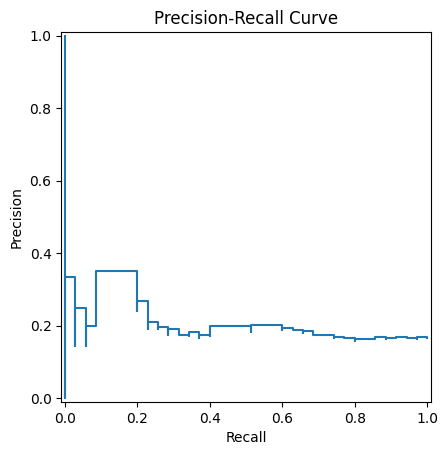

--- Threshold Tuning Resultaat ---
Berekende optimale threshold: 0.16
-----------------------------------


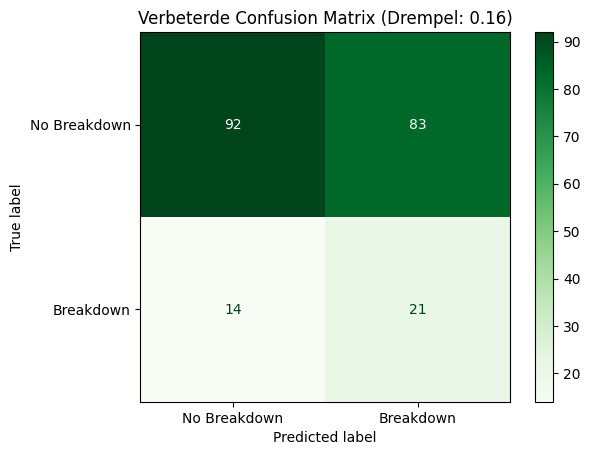


--- Getuned Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.53      0.65       175
           1       0.20      0.60      0.30        35

    accuracy                           0.54       210
   macro avg       0.53      0.56      0.48       210
weighted avg       0.76      0.54      0.60       210



In [ ]:
# --- 1. KANSEN OPHALEN ---
# In plaats van harde 0/1 voorspellingen vragen we de waarschijnlijkheid op
# We focussen op kolom [1]: de kans dat er wel een breakdown plaatsvindt
y_proba = best_rf.predict_proba(X_test)[:, 1]

# --- 2. PRECISION-RECALL CURVE ---
# Bereken de statistieken voor alle mogelijke thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Visualiseer de curve om de 'trade-off' tussen nauwkeurigheid en gevonden storingen te zien
plt.figure(figsize=(8, 5))
display = PrecisionRecallDisplay(precision=precision, recall=recall)
display.plot()
plt.title("Precision-Recall Curve")
plt.show()

# --- 3. OPTIMALE DREMPEL ZOEKEN (F1-OPTIMALISATIE) ---
# De F1-score is het harmonisch gemiddelde van precision en recall
# De drempel met de hoogste F1-score wordt gekozen als de nieuwe standaard
# We voegen 1e-9 toe om deling door nul te voorkomen bij lege klassen
# [:-1] om out of bounds te voorkomen
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]

print(f"--- Threshold Tuning Resultaat ---")
print(f"Berekende optimale threshold: {best_threshold:.2f}")
print("-" * 35)

# --- 4. EVALUATIE MET NIEUWE DREMPEL ---
# Pas de nieuwe drempel toe op de kansen om de nieuwe klasses te bepalen
y_pred_tuned = (y_proba >= best_threshold).astype(int)

# Toon de verbeterde Confusion Matrix.
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=["No Breakdown", "Breakdown"])
disp.plot(cmap=plt.cm.Greens)
plt.title(f"Verbeterde Confusion Matrix (Drempel: {best_threshold:.2f})")
plt.show()

# Toon de uiteindelijke metriek voor het getunede model.
print("\n--- Getuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

## STAP 7️⃣: Test Data Verwerken & Predictions Maken
Pas EXACT dezelfde preprocessing toe op testdata en genereer submission file

In [ ]:
# ============================================
# STAP 9: TESTDATA VERWERKEN EN VOORSPELLLINGEN MAKEN
# ============================================

# Lees testdata in (geen target labels!)
test_df = pd.read_csv(test_file)

# Sla IDs op (nodig voor submission file)
test_ids = test_df["id"]

# ============================================
# KRITIEK: Testdata EXACT HETZELFDE verwerken als traindata!
# ============================================
# Dit zorgt ervoor dat model dezelfde inputs krijgt

test_X = test_df.drop(columns=["id"]).copy()

# 1. Zet lege strings om naar NaN (identiek aan trainings-cleaning)
test_X = test_X.replace(r"^\s*$", np.nan, regex=True)

# 2. Maak missing indicators (identiek aan trainings-preprocessing)
for col in num_cols:
    test_X[col + "_missing"] = test_X[col].isna().astype(int)

# 3. Vul numerieke waarden in met TRAININGS-mediaan!
#    Mag NIET de test-mediaan gebruiken, anders leaks trainings-info
test_X[num_cols] = test_X[num_cols].fillna(medians)

# 4. Vul categorische waarden in
test_X[cat_cols] = test_X[cat_cols].fillna("missing")

# ============================================
# STAP 10: FEATURE ENGINEERING (identiek aan traindata)
# ============================================
# Dezelfde engineered features als trainings-set
test_X['mileage_per_year'] = test_X['mileage_km'] / (test_X['vehicle_age_years'] + 1e-5)
test_X['engine_hours_per_km'] = test_X['engine_hours'] / (test_X['mileage_km'] + 1e-5)
test_X['last_service_ratio'] = test_X['last_service_km_ago'] / (test_X['mileage_km'] + 1e-5)

# 5. One-hot encoding (identiek aan traindata)
test_X = pd.get_dummies(test_X, columns=cat_cols, drop_first=True, dtype=int)

# ============================================
# KRITIEK: Herindexeer naar TRAININGS-kolommen
# ============================================
# Voeg eventueel ontbrekende kolommen toe, zet gedropt kolommen op 0
# Dit zorgt ervoor dat model dezelfde features input krijgt als bij training!
test_X = test_X.reindex(columns=X.columns, fill_value=0)

# ============================================
# STAP 11: VOORSPELLEN EN SUBMISSION
# ============================================
# Maak voorspellingen met trainede model
y_probs_test = best_rf.predict_proba(test_X)[:, 1]
predictions = (y_probs_test >= best_threshold).astype(int)

# Maak output dataframe in juist format
# Kolom 1: auto ID
# Kolom 2: binaire voorspelling (0 = geen breakdown verwacht, 1 = wel)
output = pd.DataFrame({
    "id": test_ids.astype(int),
    "breakdown_next_30_days": predictions.astype(int)
})

# Schrijf naar CSV file (kan naar Kaggle geupload worden)
output.to_csv("submission.csv", mode='w', index=False)
print("Submission file created: submission.csv")

## STAP 8️⃣: Feature Importance Analyse
Analyse welke features het model gebruikt om voorspellingen te maken

In [ ]:
# ============================================
# STAP 12: FEATURE IMPORTANCE ANALYSE
# ============================================
# Welke features zijn het meest belangrijk voor het model?
# Dit helpt begrijpen wat signalen voor breakdown voorspellen

# Extract importance scores uit model
importances = pd.Series(clf_rf.feature_importances_, index=X.columns)

# Sorteer van belangrijkste naar minst belangrijk
print("=== FEATURE IMPORTANCE (Top 10) ===")
print(importances.sort_values(ascending=False).head(10))
print("\n=== ALLE FEATURES ===")
print(importances)